In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
from utils import (
    compute_shuffled_tree_energy
    )

In [ ]:
# VOCAB_PATH = Path("../data/number_ids.txt")

# grid_folder = "shuffled_tree_numbers"
# structure_name = "bin_tree"

# EMB_DIR    = Path(f"../embeddings/reps&probs32/{grid_folder}/")
# GRID_PATH  = Path(f"../data/one_random_walk/{grid_folder}/{structure_name}_structure.txt")

# hp_grid = Plotter(VOCAB_PATH, GRID_PATH, EMB_DIR)

# G = load_graph_from_txt(GRID_PATH, kind="tree")
# print("Grid - #nodi:", G.number_of_nodes(), "#archi:", G.number_of_edges())

# ctx = 2000
# WIN = 10
# PCA_K = 2
# K = 1
# MIN_NODES = PCA_K + 1

# all_results = []

# pt_path = EMB_DIR / f"reprs_bin_tree_numbers_shuffled_one_rw_2000_line000000_layer32.pt"
# ids_np, emb_np = load_embeddings_pt(pt_path)

# T_file = len(ids_np)
# t_end_ref = min(ctx, T_file)

# CONTEXT_LENS = list(range(WIN, t_end_ref + 1, WIN))
# if CONTEXT_LENS[-1] != t_end_ref:
#     CONTEXT_LENS.append(t_end_ref)

# graph_nodes = list(G.nodes())

# for win_len in CONTEXT_LENS:
#     t0 = 0#max(0, t_end_ref - win_len)
#     t1 = min(win_len, T_file)#t_end_ref

#     filtered_ids, filtered_emb = _window_and_filter(
#         ids_np, emb_np, hp_grid.id_to_word,
#         k=K,
#         t_start=t0, t_end=t1,
#         title=f"ctx={ctx}, win_len={win_len}, local=[{t0}:{t1})"
#     )

#     if len(filtered_ids) == 0:
#         all_results.append({
#             "ctx": ctx, "context_len": win_len,
#             "t_start_local": t0, "t_end_local": t1,
#             "energy": np.nan, "energy_per_edge": np.nan,
#             "n_filtered": 0, "n_centroids": 0,
#             "n_common": 0, "n_edges_subgraph": 0,
#         })
#         continue

#     centroid_ids, centroids = centroids_by_token(filtered_ids, filtered_emb)

#     if len(centroid_ids) == 0:
#         all_results.append({
#             "ctx": ctx, "context_len": win_len,
#             "t_start_local": t0, "t_end_local": t1,
#             "energy": np.nan, "energy_per_edge": np.nan,
#             "n_filtered": len(filtered_ids), "n_centroids": 0,
#             "n_common": 0, "n_edges_subgraph": 0,
#         })
#         continue

#     labels = [hp_grid.id_to_word.get(int(t), str(int(t))) for t in centroid_ids]
#     idx = {lab: i for i, lab in enumerate(labels)}
#     common = [node for node in graph_nodes if node in idx]

#     if len(common) < MIN_NODES:
#         E = E_per_edge = np.nan
#         m = 0
#     else:
#         X_common = np.stack([centroids[idx[lab]] for lab in common], axis=0).astype(np.float64)
#         X_common = X_common - X_common.mean(axis=0, keepdims=True)

#         k = min(PCA_K, len(common) - 1)
#         pca = PCA(n_components=k)
#         X_pca = pca.fit_transform(X_common)

#         G_sub = G.subgraph(common).copy()
#         m = G_sub.number_of_edges()

#         if m == 0:
#             E = E_per_edge = np.nan
#         else:
#             E = dirichlet_energy_laplacian(G_sub, common, X_pca)
#             E_per_edge = E / m

#     all_results.append({
#         "ctx": ctx, "context_len": win_len,
#         "t_start_local": t0, "t_end_local": t1,
#         "energy": E, "energy_per_edge": E_per_edge,
#         "n_filtered": len(filtered_ids), "n_centroids": len(centroid_ids),
#         "n_common": len(common), "n_edges_subgraph": m,
#     })
# df = pd.DataFrame(all_results)
# df_plot = df.dropna(subset=["energy"]).copy().sort_values("context_len")

# shuffled_tree_energy = [df_plot["context_len"].values, df_plot["energy"].values]

# fig, ax = plt.subplots(figsize=(8, 4.5))

# ax.plot(
#     shuffled_tree_energy[0], shuffled_tree_energy[1], color="tab:orange", label="Dirichlet energy"
# )
# ax.set_ylabel("Dirichlet energy")
# plt.xscale("log")

# lines1, labels1 = ax.get_legend_handles_labels()
# ax.legend(lines1, labels1, loc="best")
# plt.tight_layout()
# plt.show()

In [ ]:
# def compute_shuffled_tree_energy(
#     VOCAB_PATH: Path,
#     GRID_PATH: Path,
#     EMB_DIR: Path,
#     ctx: int = 2000,
#     WIN: int = 10,
#     PCA_K: int = 2,
#     K: int = 1,
#     MIN_NODES: int | None = None,
#     pt_filename: str | None = None,
#     graph_kind: str = "tree",
#     return_df: bool = False,
# ):
#     """
#     Restituisce:
#         shuffled_tree_energy = [df_plot["context_len"].values, df_plot["energy"].values]

#     Se return_df=True, restituisce anche df_plot.
#     """
#     if MIN_NODES is None:
#         MIN_NODES = PCA_K + 1

#     # Setup
#     hp_grid = Plotter(VOCAB_PATH, GRID_PATH, EMB_DIR)
#     G = load_graph_from_txt(GRID_PATH, kind=graph_kind)
#     graph_nodes = list(G.nodes())

#     # File embeddings
#     if pt_filename is None:
#         pt_filename = "reprs_bin_tree_one_rw_2000_line000000_layer32.pt"
#     pt_path = EMB_DIR / pt_filename

#     ids_np, emb_np = load_embeddings_pt(pt_path)

#     T_file = len(ids_np)
#     t_end_ref = min(ctx, T_file)

#     # Finestre crescenti: WIN, 2*WIN, ..., t_end_ref (assicurandolo)
#     CONTEXT_LENS = list(range(WIN, t_end_ref + 1, WIN))
#     if not CONTEXT_LENS or CONTEXT_LENS[-1] != t_end_ref:
#         CONTEXT_LENS.append(t_end_ref)

#     all_results = []

#     for win_len in CONTEXT_LENS:
#         t0 = 0
#         t1 = min(win_len, T_file)

#         filtered_ids, filtered_emb = _window_and_filter(
#             ids_np, emb_np, hp_grid.id_to_word,
#             k=K,
#             t_start=t0, t_end=t1,
#             title=f"ctx={ctx}, win_len={win_len}, local=[{t0}:{t1})"
#         )

#         if len(filtered_ids) == 0:
#             all_results.append({
#                 "ctx": ctx, "context_len": win_len,
#                 "t_start_local": t0, "t_end_local": t1,
#                 "energy": np.nan, "energy_per_edge": np.nan,
#                 "n_filtered": 0, "n_centroids": 0,
#                 "n_common": 0, "n_edges_subgraph": 0,
#             })
#             continue

#         centroid_ids, centroids = centroids_by_token(filtered_ids, filtered_emb)

#         if len(centroid_ids) == 0:
#             all_results.append({
#                 "ctx": ctx, "context_len": win_len,
#                 "t_start_local": t0, "t_end_local": t1,
#                 "energy": np.nan, "energy_per_edge": np.nan,
#                 "n_filtered": len(filtered_ids), "n_centroids": 0,
#                 "n_common": 0, "n_edges_subgraph": 0,
#             })
#             continue

#         labels = [hp_grid.id_to_word.get(int(t), str(int(t))) for t in centroid_ids]
#         idx = {lab: i for i, lab in enumerate(labels)}
#         common = [node for node in graph_nodes if node in idx]

#         if len(common) < MIN_NODES:
#             E = np.nan
#             E_per_edge = np.nan
#             m = 0
#         else:
#             X_common = np.stack([centroids[idx[lab]] for lab in common], axis=0).astype(np.float64)
#             X_common = X_common - X_common.mean(axis=0, keepdims=True)

#             k_pca = min(PCA_K, len(common) - 1)
#             pca = PCA(n_components=k_pca)
#             X_pca = pca.fit_transform(X_common)

#             G_sub = G.subgraph(common).copy()
#             m = G_sub.number_of_edges()

#             if m == 0:
#                 E = np.nan
#                 E_per_edge = np.nan
#             else:
#                 E = dirichlet_energy_laplacian(G_sub, common, X_pca)
#                 E_per_edge = E / m

#         all_results.append({
#             "ctx": ctx, "context_len": win_len,
#             "t_start_local": t0, "t_end_local": t1,
#             "energy": E, "energy_per_edge": E_per_edge,
#             "n_filtered": len(filtered_ids), "n_centroids": len(centroid_ids),
#             "n_common": len(common), "n_edges_subgraph": m,
#         })

#     df = pd.DataFrame(all_results)
#     df_plot = df.dropna(subset=["energy"]).copy().sort_values("context_len")

#     shuffled_tree_energy = [df_plot["context_len"].values, df_plot["energy"].values]

#     if return_df:
#         return shuffled_tree_energy, df_plot
#     return shuffled_tree_energy

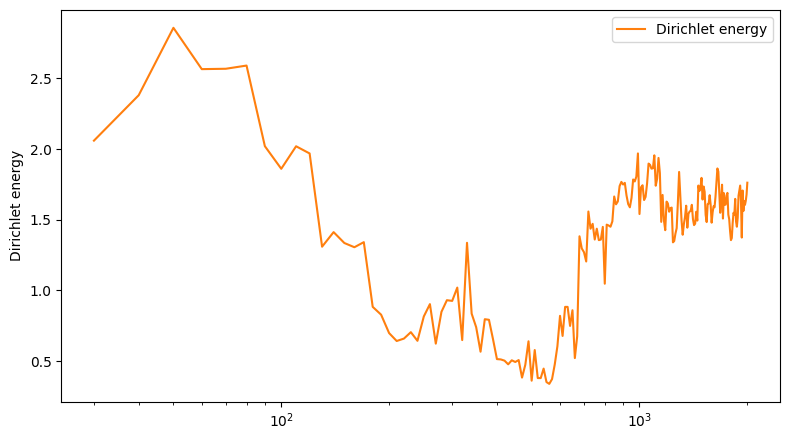

In [2]:
VOCAB_PATH = Path("../data/number_ids.txt")
grid_folder = "tree_numbers"
structure_name = "bin_tree"


EMB_DIR   = Path(f"../embeddings/reps&probs32/{grid_folder}/")
GRID_PATH = Path(f"../data/one_random_walk/{grid_folder}/{structure_name}_structure.txt")

ctx = 2000
WIN = 10
PCA_K = 2
K = 1
MIN_NODES = PCA_K + 1

shuffled_tree_energy = compute_shuffled_tree_energy(
    VOCAB_PATH=VOCAB_PATH,
    GRID_PATH=GRID_PATH,
    EMB_DIR=EMB_DIR,
    ctx=ctx,
    WIN=WIN,
    PCA_K=PCA_K,
    K=K,
    MIN_NODES=MIN_NODES,
    pt_filename="reprs_bin_tree_one_rw_2000_line000000_layer32.pt",
)


fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(
    shuffled_tree_energy[0], shuffled_tree_energy[1], color="tab:orange", label="Dirichlet energy"
)
ax.set_ylabel("Dirichlet energy")
plt.xscale("log")

lines1, labels1 = ax.get_legend_handles_labels()
ax.legend(lines1, labels1, loc="best")
plt.tight_layout()
plt.show()